In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('data_clean.csv')

In [9]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,prefix,ticket_nember
0,1,0,3,108,1,22.0,1,0,414,7.2500,3,2,0,471
1,2,1,1,190,0,38.0,1,0,503,71.2833,2,0,0,551
2,3,1,3,353,0,26.0,0,0,593,7.9250,4,2,0,632
3,4,1,1,272,0,35.0,1,0,361,53.1000,2,2,0,423
4,5,0,3,15,1,35.0,0,0,351,8.0500,3,2,0,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,887,0,2,547,1,27.0,0,0,223,13.0000,3,2,0,3
885,888,1,1,303,0,19.0,0,0,401,30.0000,1,2,0,46
886,889,0,3,412,0,25.0,1,2,600,23.4500,3,2,0,639
887,890,1,1,81,1,26.0,0,0,621,30.0000,2,0,0,658


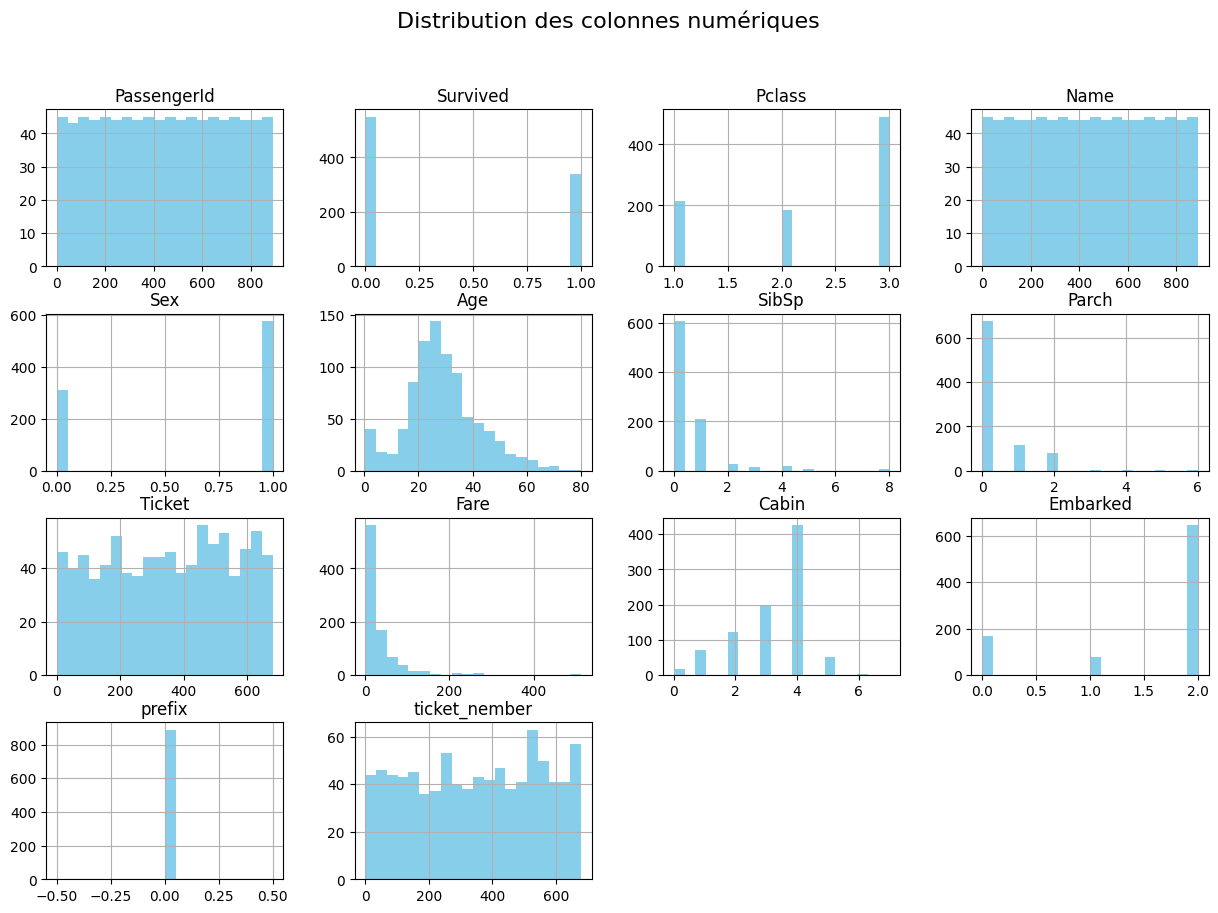

In [10]:
# Histogrammes pour toutes les colonnes numériques
df.hist(bins=20, figsize=(15,10), color='skyblue')
plt.suptitle("Distribution des colonnes numériques", fontsize=16)
plt.show()

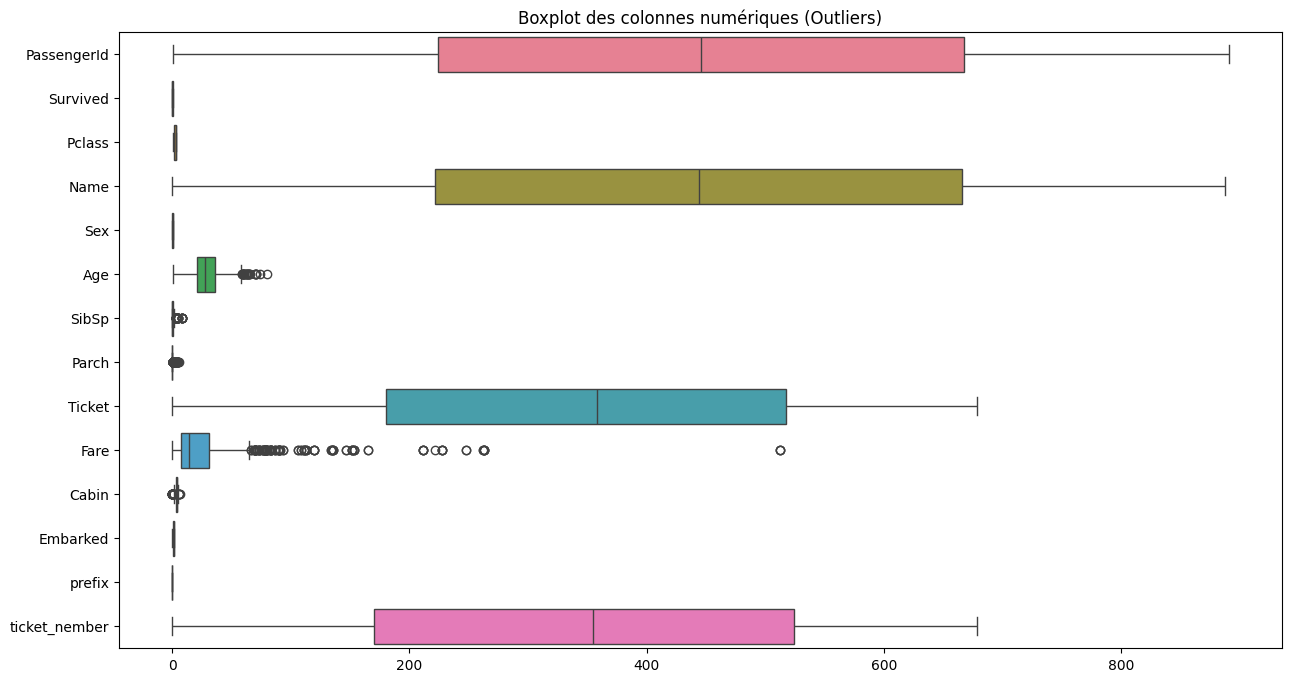

In [11]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplot des colonnes numériques (Outliers)")
plt.show()

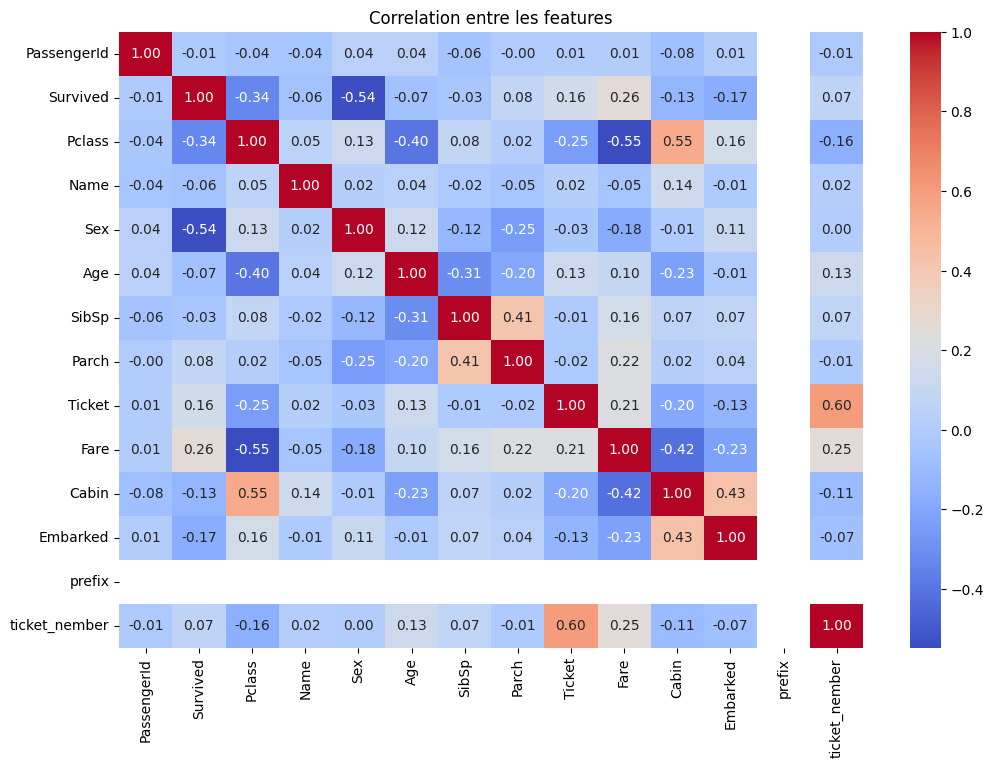

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation entre les features")
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


X = df.drop(columns=['Survived','PassengerId','Name','Ticket','ticket_nember'])
y = df['Survived']

# X['Age'].fillna(X['Age'].median(), inplace=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=2,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.2,
    reg_lambda=1.5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8314606741573034
Precision: 0.8166666666666667
Recall: 0.7205882352941176
F1-score: 0.765625
ROC AUC: 0.8618315508021391


/tmp/ipykernel_21098/3030641769.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x="Metric", y="Score", palette="viridis")


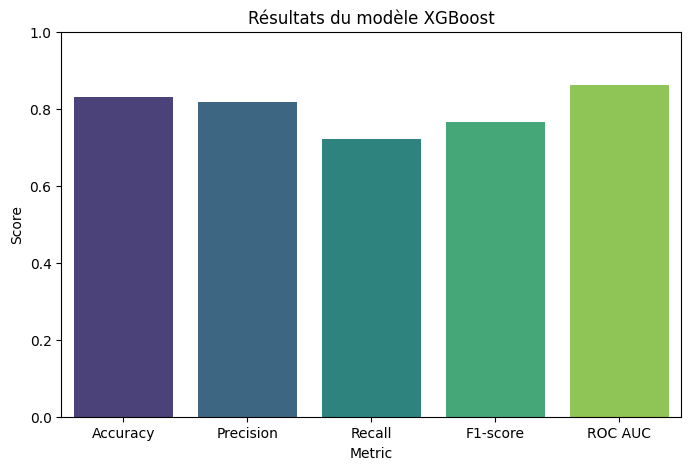

In [13]:
# Metrics du modèle
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
    "Score": [0.8315, 0.8167, 0.7206, 0.7656, 0.8618]
}

metrics_df = pd.DataFrame(metrics)

plt.figure(figsize=(8,5))
sns.barplot(data=metrics_df, x="Metric", y="Score", palette="viridis")
plt.ylim(0,1)
plt.title("Résultats du modèle XGBoost")
plt.show()

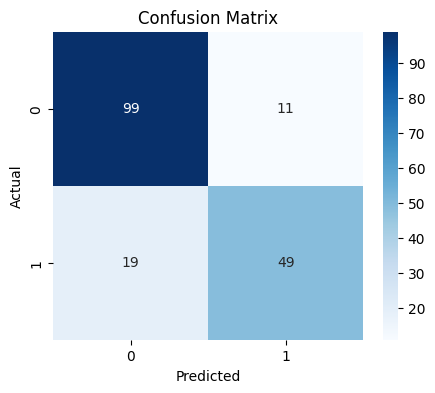

In [14]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()